In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import seaborn as sns
import json
import joblib


In [2]:
with open("../saved_models/features.json") as f:
    feature_names = json.load(f)


In [3]:
df = pd.read_csv("../data/processed/final_dataset2.csv", parse_dates=["timestamp"])
df.head()

,timestamp,load_actual,temperature,humidity,dew_point,solar_generation,wind_generation
0,2014-12-31 23:00:00,9484.0,0.5,96.0,-0.1,92.66,734.81
1,2015-01-01 00:00:00,9484.0,0.1,95.0,-0.5,92.66,734.81
2,2015-01-01 01:00:00,9152.0,-0.2,95.0,-0.9,92.66,734.81
3,2015-01-01 02:00:00,8799.0,-0.4,95.0,-1.2,92.66,766.64
4,2015-01-01 03:00:00,8567.0,-0.6,95.0,-1.3,92.66,733.13


In [4]:
target = "load_actual"
drop_cols = ["timestamp", "load_actual"]

X = df.drop(columns=drop_cols)
y = df[target]


In [11]:
train_size = int(len(df) * 0.8)

X_train = X.iloc[:train_size][feature_names]
X_test  = X.iloc[train_size:][feature_names]

y_train = y.iloc[:train_size]
y_test  = y.iloc[train_size:]



Function to calculate Mean Absolute Percentage Error (MAPE)

In [12]:
def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100


LightGBM Regressor

In [13]:
import lightgbm as lgb

lgb_model = lgb.LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

lgb_model.fit(X_train, y_train)
pred_lgb = lgb_model.predict(X_test)

mae_lgb = mean_absolute_error(y_test, pred_lgb)
rmse_lgb = mean_squared_error(y_test, pred_lgb) ** 0.5
mape_lgb = mean_absolute_percentage_error(y_test, pred_lgb)

print("LightGBM Results:")
print("MAE:", mae_lgb)
print("RMSE:", rmse_lgb)
print("MAPE:", mape_lgb)

joblib.dump(lgb_model, "../saved_models/lgb_model.pkl")


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001097 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 70120, number of used features: 5
[LightGBM] [Info] Start training from score 9937.403895
LightGBM Results:
MAE: 822.2024633045052
RMSE: 1015.8937587871955
MAPE: 8.646870069485736


['../saved_models/lgb_model.pkl']

CatBoost Regressor

In [14]:
from catboost import CatBoostRegressor

cat_model = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=8,
    loss_function='RMSE',
    verbose=False
)

cat_model.fit(X_train, y_train)

pred_cat = cat_model.predict(X_test)

mae_cat = mean_absolute_error(y_test, pred_cat)
rmse_cat = mean_squared_error(y_test, pred_cat) ** 0.5
mape_cat = mean_absolute_percentage_error(y_test, pred_cat)

print("CatBoost Results:")
print("MAE:", mae_cat)
print("RMSE:", rmse_cat)
print("MAPE:", mape_cat)

cat_model.save_model("../saved_models/catboost_model.cbm")


CatBoost Results:
MAE: 837.9893344115528
RMSE: 1031.8333734217356
MAPE: 8.809817885852382


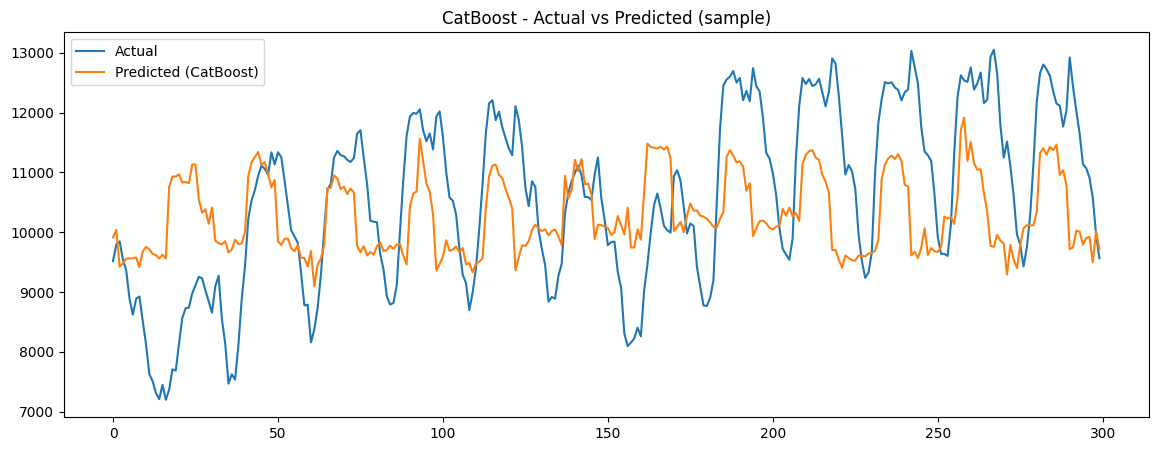

In [15]:
plt.figure(figsize=(14,5))
plt.plot(y_test.values[:300], label="Actual")
plt.plot(pred_cat[:300], label="Predicted (CatBoost)")
plt.legend()
plt.title("CatBoost - Actual vs Predicted (sample)")
plt.show()
